## Part 3

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

In [2]:
# 3.1 Getting the DATA

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention, matching the GWLandscape figures you saw in Part 2:
#   star 1 = red, star 2 = blue, whole system = black.
# We ALSO vary linestyle, so the plots stay readable in greyscale / for colour-blind readers.
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"

DATA_PATH = Path("../../../data/BSE_Detailed_Output_0.h5")
print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.5


In [3]:
# 3.2 Inspecting the DATA

with h5py.File(DATA_PATH, "r") as f:
    keys = list(f.keys())
    print(f"The file contains {len(keys)} columns, each with {f[keys[0]].shape[0]} timesteps.\n")
    print(f"{'column':32s} {'units':18s}     dtype")
    print("-" * 64)
    for k in keys:
        units = f[k].attrs.get("units", b"?")
        units = units.decode() if isinstance(units, bytes) else str(units)
        print(f"{k:32s} {units:18s} {f[k].dtype}")

The file contains 81 columns, each with 3951 timesteps.

column                           units                  dtype
----------------------------------------------------------------
Age(1)                           Myr                float64
Age(2)                           Myr                float64
Ang_Momentum(1)                  Msol AU^2 yr^-1    float64
Ang_Momentum(2)                  Msol AU^2 yr^-1    float64
Ang_Momentum_Total               Msol AU^2 yr^-1    float64
Beta                             -                  float64
Dominant_Mass_Loss_Rate(1)       -                  int32
Dominant_Mass_Loss_Rate(2)       -                  int32
Eccentricity                     -                  float64
Energy_Total                     Msol AU^2 yr^-2    float64
Luminosity(1)                    Lsol               float64
Luminosity(2)                    Lsol               float64
MT_History                       -                  int32
Mass(1)                          Msol     

In [4]:
# 3.2 Loading the DATA into a pandas DataFrame

COLUMNS = [
    "Time", "dT",
    "Mass(1)", "Mass(2)", "Mass_He_Core(1)", "Mass_He_Core(2)", "Mass_CO_Core(1)", "Mass_CO_Core(2)",
    "Radius(1)", "Radius(2)", "RocheLobe(1)", "RocheLobe(2)", "SemiMajorAxis", "Eccentricity",
    "Stellar_Type(1)", "Stellar_Type(2)", "Luminosity(1)", "Luminosity(2)", "Teff(1)", "Teff(2)",
    "MT_History", "Unbound"]
with h5py.File(DATA_PATH, "r") as f:
    df = pd.DataFrame({c: f[c][()] for c in COLUMNS})
    Z_ZAMS = f["Metallicity@ZAMS(1)"][0]
    M1_ZAMS, M2_ZAMS = f["Mass@ZAMS(1)"][0], f["Mass@ZAMS(2)"][0]

print(f"Loaded {len(df)} timesteps spanning {df.Time.min():.2f} to {df.Time.max():.2f} Myr\n")
print("Initial conditions read back from the file:")
print(f"  M1 = {M1_ZAMS:.2f} Msun,  M2 = {M2_ZAMS:.2f} Msun")
print(f"  Z  = {Z_ZAMS:.4f}")
print(f"  a  = {df['SemiMajorAxis'].iloc[0]:.2f} Rsun  ({df['SemiMajorAxis'].iloc[0]/215.032:.2f} AU)")
print(f"  e  = {df['Eccentricity'].iloc[0]:.2f}")

df.head()

Loaded 3951 timesteps spanning 0.00 to 7.89 Myr

Initial conditions read back from the file:
  M1 = 35.00 Msun,  M2 = 31.00 Msun
  Z  = 0.0010
  a  = 752.61 Rsun  (3.50 AU)
  e  = 0.00


,Time,dT,Mass(1),Mass(2),Mass_He_Core(1),Mass_He_Core(2),Mass_CO_Core(1),Mass_CO_Core(2),Radius(1),Radius(2),...,SemiMajorAxis,Eccentricity,Stellar_Type(1),Stellar_Type(2),Luminosity(1),Luminosity(2),Teff(1),Teff(2),MT_History,Unbound
0,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
1,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
2,0.0,0.0,35.000000,31.000000,0.0,0.0,0.0,0.0,6.202891,5.782145,...,752.612545,0.0,1,1,159141.587811,120656.591940,46336.837215,44783.784745,0,0
3,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,752.612653,0.0,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0
4,0.0,0.0,34.999994,30.999996,0.0,0.0,0.0,0.0,6.202890,5.782145,...,752.612653,0.0,1,1,159141.529025,120656.558309,46336.835129,44783.783192,0,0


In [5]:
# 3.3 COMPAS stellar type codes -- from src/typedefs.h in the COMPAS source
STELLAR_TYPES = {
    0:  "MS (<= 0.7 Msun)",
    1:  "Main sequence",
    2:  "Hertzsprung gap",
    3:  "First giant branch",
    4:  "Core helium burning",
    5:  "Early AGB",
    6:  "Thermally pulsing AGB",
    7:  "Naked helium star MS",
    8:  "Naked helium star HG",
    9:  "Naked helium star GB",
    10: "Helium white dwarf",
    11: "Carbon-oxygen white dwarf",
    12: "Oxygen-neon white dwarf",
    13: "Neutron star",
    14: "Black hole",
    15: "Massless remnant",
    16: "Chemically homogeneous",
}

# COMPAS mass transfer tracking codes -- MT_TRACKING enum in src/typedefs.h
MT_HISTORY = {
    0: "No mass transfer",
    1: "Stable mass transfer: star 1 -> star 2",
    2: "Stable mass transfer: star 2 -> star 1",
    3: "Common envelope: star 1 -> star 2 (survived)",
    4: "Common envelope: star 2 -> star 1 (survived)",
    5: "Common envelope: double-core (survived)",
    6: "Merger",
}

print("Stellar types visited by star 1:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(1)"])])
print("Stellar types visited by star 2:",
      [STELLAR_TYPES[t] for t in dict.fromkeys(df["Stellar_Type(2)"])])
print("\nMass transfer episodes recorded:",
      [MT_HISTORY[t] for t in sorted(set(df["MT_History"])) if t != 0])

Stellar types visited by star 1: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']
Stellar types visited by star 2: ['Main sequence', 'Hertzsprung gap', 'Core helium burning', 'Naked helium star MS', 'Naked helium star HG', 'Black hole']

Mass transfer episodes recorded: ['Stable mass transfer: star 1 -> star 2', 'Common envelope: star 2 -> star 1 (survived)']


In [6]:
# 3.4 Building An Event Timeline

def find_events(df):
    '''Return a DataFrame of moments where a stellar type or mass transfer state changed.'''
    events = []

    for star, colour in [(1, "star 1"), (2, "star 2")]:
        st = df[f"Stellar_Type({star})"].values
        for i in np.where(np.diff(st) != 0)[0]:
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1],
                "event": f"{colour}: {STELLAR_TYPES[st[i]]} -> {STELLAR_TYPES[st[i + 1]]}",
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    mt = df["MT_History"].values
    for i in np.where(np.diff(mt) != 0)[0]:
        if mt[i + 1] != 0:  # only report the *start* of an episode
            events.append({
                "Time [Myr]": df["Time"].iloc[i + 1],
                "event": f"*** {MT_HISTORY[mt[i + 1]]} ***",
                "M1": df["Mass(1)"].iloc[i + 1],
                "M2": df["Mass(2)"].iloc[i + 1],
                "a [Rsun]": df["SemiMajorAxis"].iloc[i + 1],
            })

    return pd.DataFrame(events).sort_values("Time [Myr]").reset_index(drop=True)


events = find_events(df)
events.round(2)

,Time [Myr],event,M1,M2,a [Rsun]
0,5.89,star 1: Main sequence -> Hertzsprung gap,33.68,30.20,777.64
1,5.89,star 1: Hertzsprung gap -> Core helium burning,33.67,30.20,777.71
2,6.13,star 1: Core helium burning -> Naked helium st...,12.36,30.14,787.02
3,6.13,*** Stable mass transfer: star 1 -> star 2 ***,12.36,30.14,787.02
4,6.47,star 1: Naked helium star MS -> Naked helium s...,12.29,35.83,2004.74
5,6.48,star 1: Naked helium star HG -> Black hole,9.73,35.82,2005.54
6,7.32,star 2: Main sequence -> Hertzsprung gap,9.73,35.44,2151.65
7,7.33,star 2: Hertzsprung gap -> Core helium burning,9.73,35.43,2151.98
8,7.58,star 2: Core helium burning -> Naked helium st...,9.73,13.31,9.09
9,7.58,*** Common envelope: star 2 -> star 1 (survive...,9.73,13.31,9.09


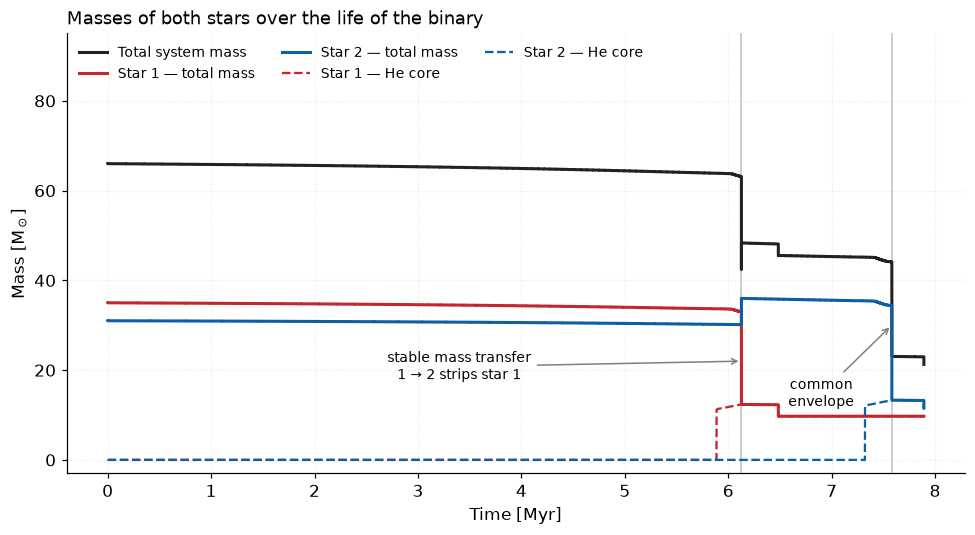

In [7]:
# 3.5 PLOT 1: Masses over time

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df.Time, df["Mass(1)"] + df["Mass(2)"], color=CSYS, lw=2, label="Total system mass")
ax.plot(df.Time, df["Mass(1)"], color=C1, lw=2, label="Star 1 — total mass")
ax.plot(df.Time, df["Mass(2)"], color=C2, lw=2, label="Star 2 — total mass")
ax.plot(df.Time, df["Mass_He_Core(1)"], color=C1, lw=1.5, ls="--", label="Star 1 — He core")
ax.plot(df.Time, df["Mass_He_Core(2)"], color=C2, lw=1.5, ls="--", label="Star 2 — He core")

# annotate the two interaction episodes
for _, ev in events[events.event.str.startswith("***")].iterrows():
    ax.axvline(ev["Time [Myr]"], color="grey", lw=1, ls="-", alpha=0.5, zorder=0)

ax.set_ylim(-3, 95)  # headroom so the legend sits clear above the data
ax.annotate("stable mass transfer\n1 → 2 strips star 1",
            xy=(6.13, 22), xytext=(3.4, 18), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate("common\nenvelope", xy=(7.58, 30), xytext=(6.9, 12), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))

ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Mass [M$_\odot$]")
ax.set_title("Masses of both stars over the life of the binary", loc="left", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

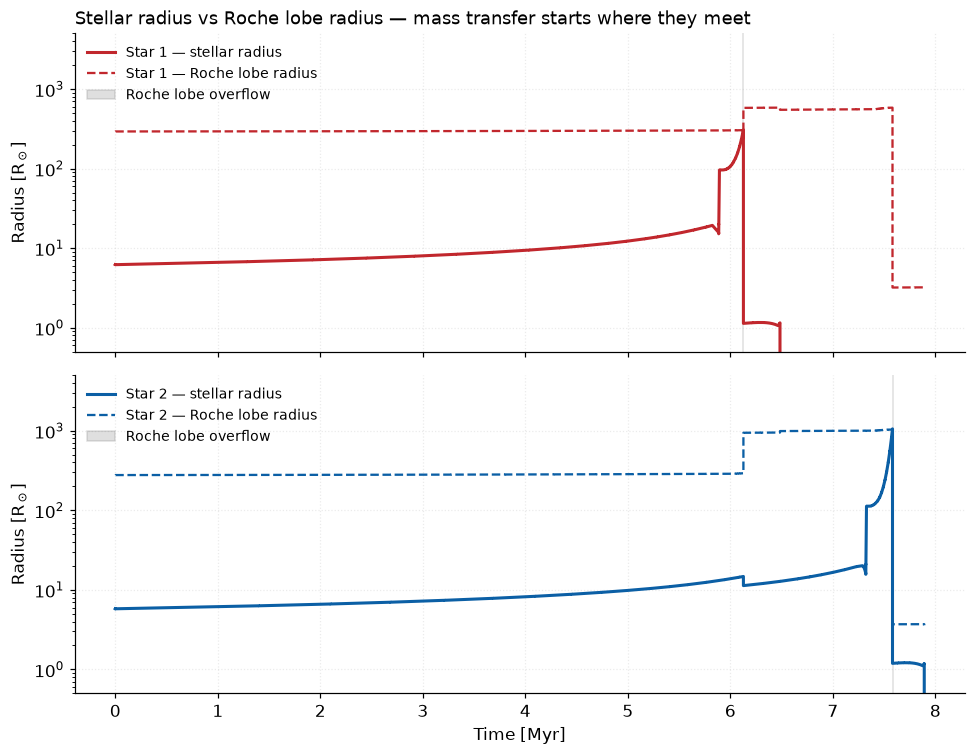

In [8]:
# 3.6 PLOT 2: Stellar radii vs Roche lobe radii

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for ax, star, colour in [(axes[0], 1, C1), (axes[1], 2, C2)]:
    ax.plot(df.Time, df[f"Radius({star})"], color=colour, lw=2,
            label=f"Star {star} — stellar radius")
    ax.plot(df.Time, df[f"RocheLobe({star})"], color=colour, lw=1.5, ls="--",
            label=f"Star {star} — Roche lobe radius")

    # shade the intervals where this star overflows its Roche lobe
    overflowing = df[f"Radius({star})"] >= df[f"RocheLobe({star})"]
    ax.fill_between(df.Time, 1e-2, 1e4, where=overflowing, color="grey", alpha=0.25,
                    label="Roche lobe overflow", zorder=0)

    ax.set_yscale("log")
    ax.set_ylim(0.5, 5e3)
    ax.set_ylabel(r"Radius [R$_\odot$]")
    ax.legend(loc="upper left", fontsize=9)

axes[0].set_title("Stellar radius vs Roche lobe radius — mass transfer starts where they meet",
                  loc="left", fontsize=12)
axes[1].set_xlabel("Time [Myr]")
plt.tight_layout()
plt.show()

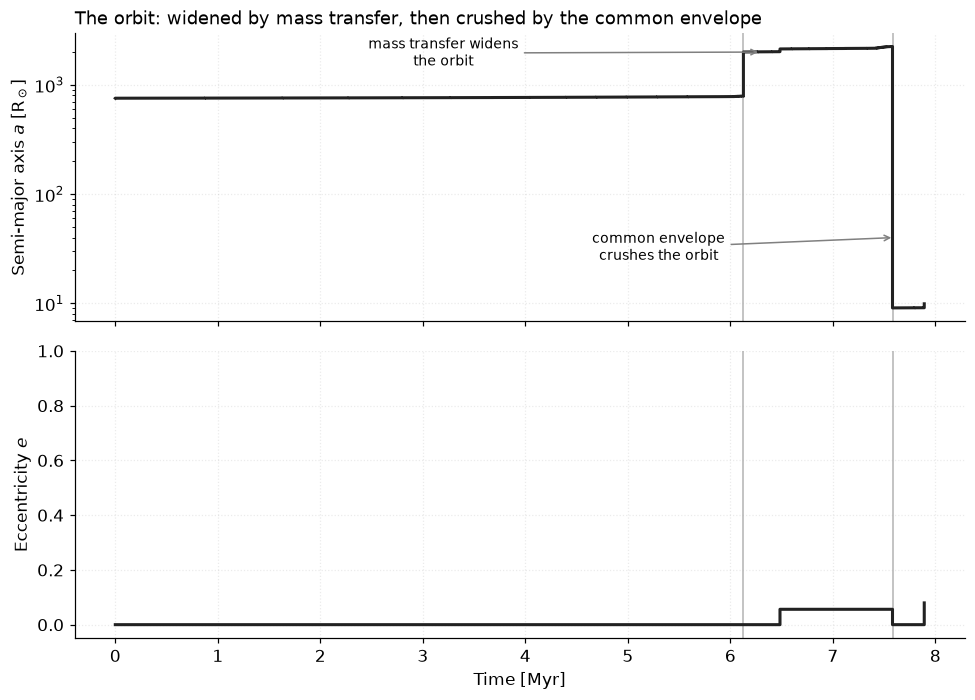

Separation just before the common envelope :  2109.80 Rsun
Separation just after  the common envelope :     9.09 Rsun
  --> the CE shrank the orbit by a factor of 232.1
Final separation of the binary black hole   :     9.91 Rsun


In [9]:
# 3.7 PLOT 3: Semi-major axis and eccentricity over time

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

axes[0].plot(df.Time, df["SemiMajorAxis"], color=CSYS, lw=2)
axes[0].set_yscale("log")
axes[0].set_ylabel(r"Semi-major axis $a$ [R$_\odot$]")
axes[0].set_title("The orbit: widened by mass transfer, then crushed by the common envelope",
                  loc="left", fontsize=12)

axes[1].plot(df.Time, df["Eccentricity"], color=CSYS, lw=2)
axes[1].set_ylabel("Eccentricity $e$")
axes[1].set_xlabel("Time [Myr]")
axes[1].set_ylim(-0.05, 1.0)

for ax in axes:
    for _, ev in events[events.event.str.startswith("***")].iterrows():
        ax.axvline(ev["Time [Myr]"], color="grey", lw=1, alpha=0.6, zorder=0)

axes[0].annotate("mass transfer widens\nthe orbit", xy=(6.3, 1990), xytext=(3.2, 1500),
                 fontsize=9, ha="center",
                 arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[0].annotate("common envelope\ncrushes the orbit", xy=(7.6, 40), xytext=(5.3, 25),
                 fontsize=9, ha="center",
                 arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

# Find the common envelope from the data itself (MT_History == 4), rather than
# hard-coding a time: the row before it starts is the orbit "just before" the CE.
ce_start = np.where(df["MT_History"].values == 4)[0][0]
a_before = df["SemiMajorAxis"].iloc[ce_start - 1]
a_at_ce = df["SemiMajorAxis"].iloc[ce_start]
a_final = df["SemiMajorAxis"].iloc[-1]

print(f"Separation just before the common envelope : {a_before:8.2f} Rsun")
print(f"Separation just after  the common envelope : {a_at_ce:8.2f} Rsun")
print(f"  --> the CE shrank the orbit by a factor of {a_before / a_at_ce:.1f}")
print(f"Final separation of the binary black hole   : {a_final:8.2f} Rsun")

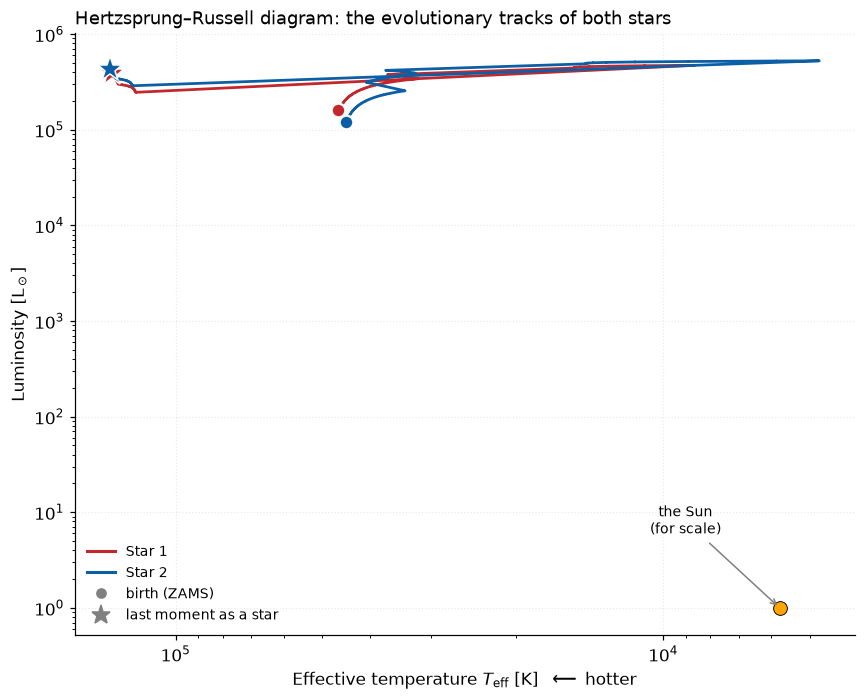

In [10]:
# 3.8 PLOT 4: Hertzsprung–Russell diagram

fig, ax = plt.subplots(figsize=(8, 6.5))

# only plot while each object is still a star -- black holes have no meaningful Teff/L
for star, colour, name in [(1, C1, "Star 1"), (2, C2, "Star 2")]:
    is_star = df[f"Stellar_Type({star})"] <= 9
    d = df[is_star]
    ax.plot(d[f"Teff({star})"], d[f"Luminosity({star})"], color=colour, lw=1.8, label=name)
    ax.plot(d[f"Teff({star})"].iloc[0], d[f"Luminosity({star})"].iloc[0],
            "o", color=colour, ms=9, mec="white", mew=1.5)
    ax.plot(d[f"Teff({star})"].iloc[-1], d[f"Luminosity({star})"].iloc[-1],
            "*", color=colour, ms=17, mec="white", mew=1)

# the Sun, for scale -- note how far below these massive stars it sits
ax.plot(5772, 1.0, "o", color="orange", ms=9, mec="black", mew=0.6)
ax.annotate("the Sun\n(for scale)", xy=(5772, 1.0), xytext=(9000, 6), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()  # HR convention: hot on the LEFT
ax.set_xlabel(r"Effective temperature $T_{\rm eff}$ [K]  $\longleftarrow$ hotter")
ax.set_ylabel(r"Luminosity [L$_\odot$]")
ax.set_title("Hertzsprung–Russell diagram: the evolutionary tracks of both stars",
             loc="left", fontsize=12)

handles = [Line2D([], [], color=C1, lw=2, label="Star 1"),
           Line2D([], [], color=C2, lw=2, label="Star 2"),
           Line2D([], [], color="grey", marker="o", ls="none", label="birth (ZAMS)"),
           Line2D([], [], color="grey", marker="*", ls="none", ms=13,
                  label="last moment as a star")]
ax.legend(handles=handles, loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

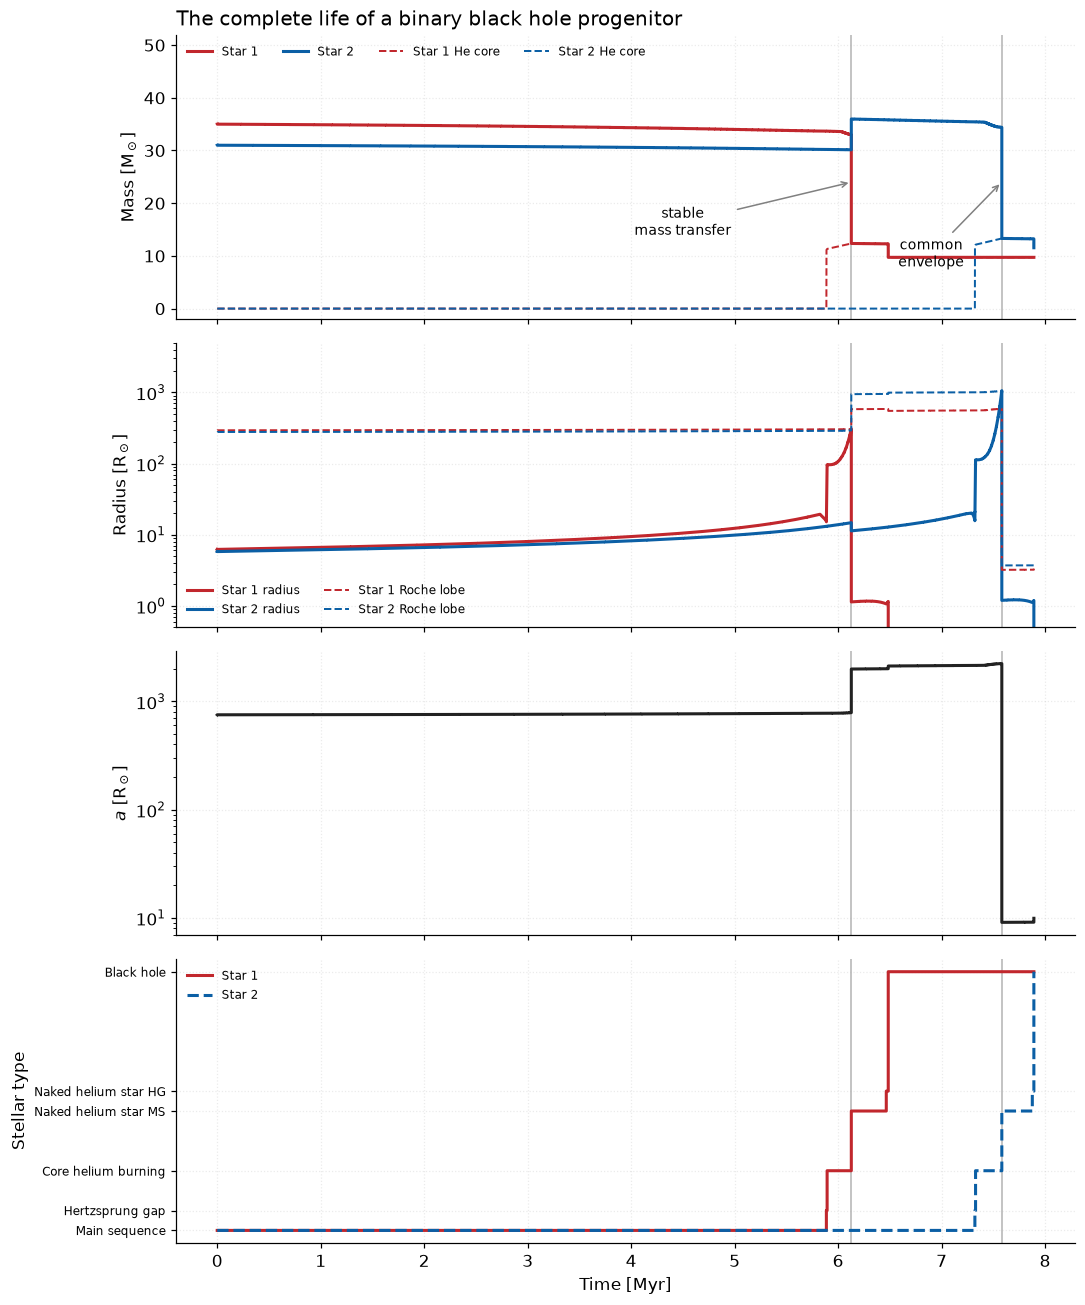

FINAL STATE at t = 7.89 Myr
  Star 1: Black hole, 9.73 Msun
  Star 2: Black hole, 11.54 Msun
  Separation: 9.91 Rsun, eccentricity 0.079
  Bound? YES - still a binary


In [11]:
# 3.9 All panels together

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# --- panel 1: masses -----------------------------------------------------------
ax = axes[0]
ax.plot(df.Time, df["Mass(1)"], color=C1, lw=2, label="Star 1")
ax.plot(df.Time, df["Mass(2)"], color=C2, lw=2, label="Star 2")
ax.plot(df.Time, df["Mass_He_Core(1)"], color=C1, lw=1.3, ls="--", label="Star 1 He core")
ax.plot(df.Time, df["Mass_He_Core(2)"], color=C2, lw=1.3, ls="--", label="Star 2 He core")
ax.set_ylabel(r"Mass [M$_\odot$]")
ax.set_ylim(-2, 52)  # headroom for the legend and annotations
ax.legend(fontsize=8, ncol=4, loc="upper left")
ax.set_title("The complete life of a binary black hole progenitor", loc="left", fontsize=13)

# --- panel 2: radii and Roche lobes --------------------------------------------
ax = axes[1]
ax.plot(df.Time, df["Radius(1)"], color=C1, lw=2, label="Star 1 radius")
ax.plot(df.Time, df["Radius(2)"], color=C2, lw=2, label="Star 2 radius")
ax.plot(df.Time, df["RocheLobe(1)"], color=C1, lw=1.3, ls="--", label="Star 1 Roche lobe")
ax.plot(df.Time, df["RocheLobe(2)"], color=C2, lw=1.3, ls="--", label="Star 2 Roche lobe")
ax.set_yscale("log")
# Clip the y-axis to stellar radii: after collapse the "radius" is the compact
# object's (~1e-4 Rsun, a few km), which would otherwise squash the whole panel.
ax.set_ylim(0.5, 5e3)
ax.set_ylabel(r"Radius [R$_\odot$]")
ax.legend(fontsize=8, ncol=2, loc="lower left")

# --- panel 3: separation -------------------------------------------------------
ax = axes[2]
ax.plot(df.Time, df["SemiMajorAxis"], color=CSYS, lw=2)
ax.set_yscale("log")
ax.set_ylabel(r"$a$ [R$_\odot$]")

# --- panel 4: stellar type -----------------------------------------------------
ax = axes[3]
ax.step(df.Time, df["Stellar_Type(1)"], color=C1, lw=2, where="post", label="Star 1")
ax.step(df.Time, df["Stellar_Type(2)"], color=C2, lw=2, where="post", ls="--", label="Star 2")
visited = sorted(set(df["Stellar_Type(1)"]) | set(df["Stellar_Type(2)"]))
ax.set_yticks(visited)
ax.set_yticklabels([STELLAR_TYPES[t] for t in visited], fontsize=8)
ax.set_ylabel("Stellar type")
ax.set_xlabel("Time [Myr]")
ax.legend(fontsize=8, loc="upper left")

# mark the interaction events across every panel
for ax in axes:
    for _, ev in events[events.event.str.startswith("***")].iterrows():
        ax.axvline(ev["Time [Myr]"], color="grey", lw=1, alpha=0.6, zorder=0)

axes[0].annotate("stable\nmass transfer", xy=(6.13, 24), xytext=(4.5, 14), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
axes[0].annotate("common\nenvelope", xy=(7.58, 24), xytext=(6.9, 8), fontsize=9,
                 ha="center", arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

print(f"FINAL STATE at t = {df.Time.iloc[-1]:.2f} Myr")
print(f"  Star 1: {STELLAR_TYPES[df['Stellar_Type(1)'].iloc[-1]]}, {df['Mass(1)'].iloc[-1]:.2f} Msun")
print(f"  Star 2: {STELLAR_TYPES[df['Stellar_Type(2)'].iloc[-1]]}, {df['Mass(2)'].iloc[-1]:.2f} Msun")
print(f"  Separation: {df['SemiMajorAxis'].iloc[-1]:.2f} Rsun, eccentricity {df['Eccentricity'].iloc[-1]:.3f}")
print(f"  Bound? {'NO - disrupted' if df['Unbound'].iloc[-1] else 'YES - still a binary'}")